In [1]:
from lib.contact_settings import *
from lib.contact_wheel_rail import wheel, rail
from lib.contact_dyn_state import dynamic_state
from lib.contact_solver import patch_search
from lib.contact_material import material
from lib.contact_methods import eqv_el_normal_contact
import matplotlib.pyplot as plt

In [2]:
Wheel_1 = wheel(lr=LEFT)
Wheel_2 = wheel()
Rai_1 = rail(lr=LEFT)
Rai_2 = rail()

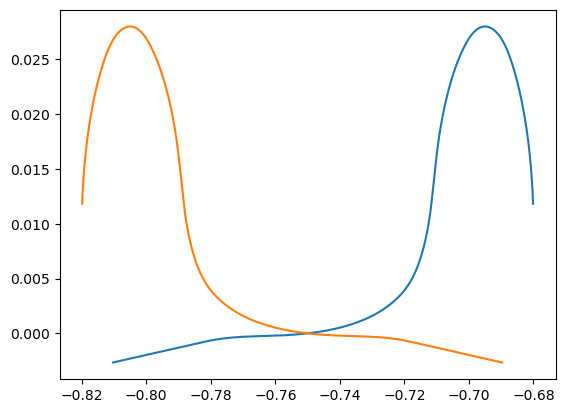

In [3]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_start_pos[:,0], Wheel_1.wheel_start_pos[:,1])
ax.plot(Wheel_2.wheel_start_pos[:,0]-0.75*2, Wheel_2.wheel_start_pos[:,1])

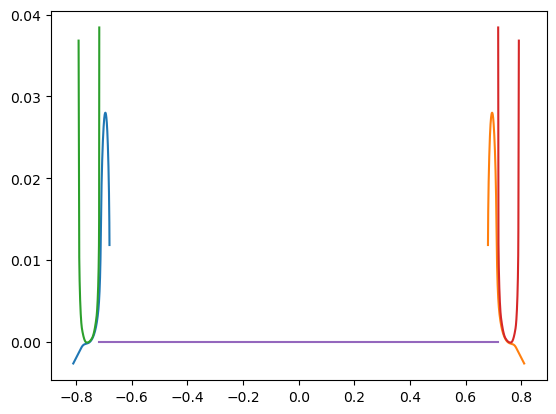

In [4]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_start_pos[:,0], Wheel_1.wheel_start_pos[:,1])
ax.plot(Wheel_2.wheel_start_pos[:,0], Wheel_2.wheel_start_pos[:,1])
ax.plot(Rai_1.rail_start_pos[:,0], Rai_1.rail_start_pos[:,1])
ax.plot(Rai_2.rail_start_pos[:,0], Rai_2.rail_start_pos[:,1])
ax.plot([-Rai_1.gauge/2, Rai_1.gauge/2],[0,0])

In [5]:
# new_state = dynamic_state(state_yaw=3*np.pi/180)
# new_state = dynamic_state(state_y=0, state_yaw=3*np.pi/180)
new_state = dynamic_state()

print(new_state.state_y)

0


In [6]:
Wheel_dyn_0 = wheel(lr=RIGHT)
Wheel_dyn_1 = wheel(lr=LEFT)

# Need check thge left wheel because it gives wierd results

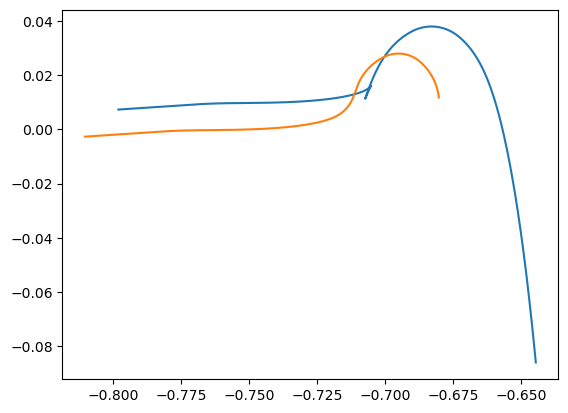

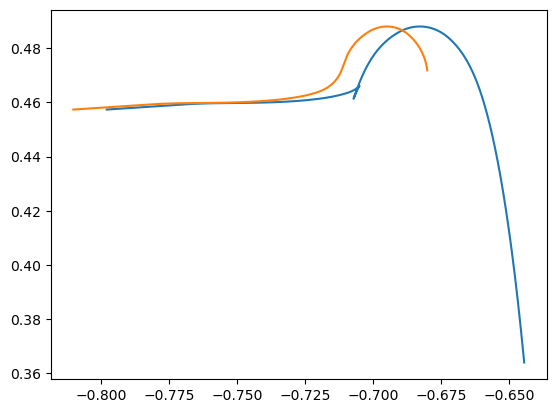

In [7]:
# new_state = dynamic_state(state_y=0, state_yaw=0)
new_state.state_yaw = 1.5*3*np.pi/180
new_state.state_y = 0.01
new_state.state_z = 0.01
Wheel_dyn_1.set_dynamic_state(new_state)
Wheel_dyn_1.calculate_position()

fig, ax = plt.subplots()
ax.plot(Wheel_dyn_1.wheel_profile_pos[:,0], Wheel_dyn_1.wheel_profile_pos[:,1])
ax.plot(Wheel_dyn_1.wheel_start_pos[:,0], Wheel_dyn_1.wheel_start_pos[:,1])

fig, ax = plt.subplots()
ax.plot(Wheel_dyn_1.wheel_radius[:,0], Wheel_dyn_1.wheel_radius[:,1])
# ax.plot(Wheel_dyn_1.wheel_profile_pos[:,0], Wheel_dyn_1.wheel_profile_pos[:,1])
ax.plot(Wheel_dyn_1.wheel_start_radius[:,0], Wheel_dyn_1.wheel_start_radius[:,1])

In [8]:
Wheel_1 = wheel(lr=LEFT)
Wheel_2 = wheel()
Rai_1 = rail(lr=LEFT)
Rai_2 = rail()

material_model = material()
contact_patches = [eqv_el_normal_contact(), eqv_el_normal_contact(), eqv_el_normal_contact()]

new_state = dynamic_state(state_z = 0.0001)
Wheel_1.set_dynamic_state(new_state)
Wheel_1.calculate_position()

patch_search(Wheel_1, Rai_1, material_model, contact_patches)

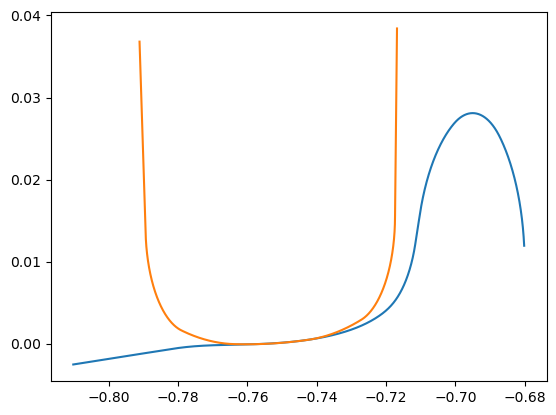

In [9]:
fig, ax = plt.subplots()
ax.plot(Wheel_1.wheel_profile_pos[:,0], Wheel_1.wheel_profile_pos[:,1])
ax.plot(Rai_1.rail_profile_pos[:,0], Rai_1.rail_profile_pos[:,1])

In [10]:
from calc_routines.determine_static_contact import static_contact

In [19]:
deltays = np.arange(-20e-3, 20e-3 + 0.05e-3, 0.05e-3)

Wheel = wheel()
Rail = rail(rail_inclination=20)

material_model = material()
contact_patches = [eqv_el_normal_contact(), eqv_el_normal_contact(), eqv_el_normal_contact()]


In [20]:
stuff = static_contact(deltays, Wheel, Rail, contact_patches, material_model)

c:\Users\rocco\Desktop\PPP\prove\gitRepo\SimRail\calc_routines\determine_static_contact.py:99: RuntimeWarning: The iteration is not making good progress, as measured by the 
  improvement from the last ten iterations.
  root = fsolve(


In [21]:
print(len(stuff))
print(stuff)

801
[[ 3.49236095e-04  5.00360108e+04  5.00000000e+04  7.31003698e-05
   6.08466748e-03  3.17368744e-03]
 [ 3.47342787e-04  5.00358009e+04  5.00000000e+04  7.31055905e-05
   6.08387539e-03  3.17368755e-03]
 [ 3.45454556e-04  5.00356337e+04  5.00000000e+04  7.31110665e-05
   6.08305577e-03  3.17368769e-03]
 ...
 [-1.97036248e-02  6.12042633e+04  5.00000000e+04  1.08785360e-04
   8.39627746e-03  9.60173332e-04]
 [-1.97386873e-02  6.11272355e+04  5.00000000e+04  1.08537491e-04
   8.39661517e-03  9.63542020e-04]
 [-1.97738696e-02  6.10397193e+04  5.00000000e+04  1.08434228e-04
   8.39067278e-03  9.63631329e-04]]


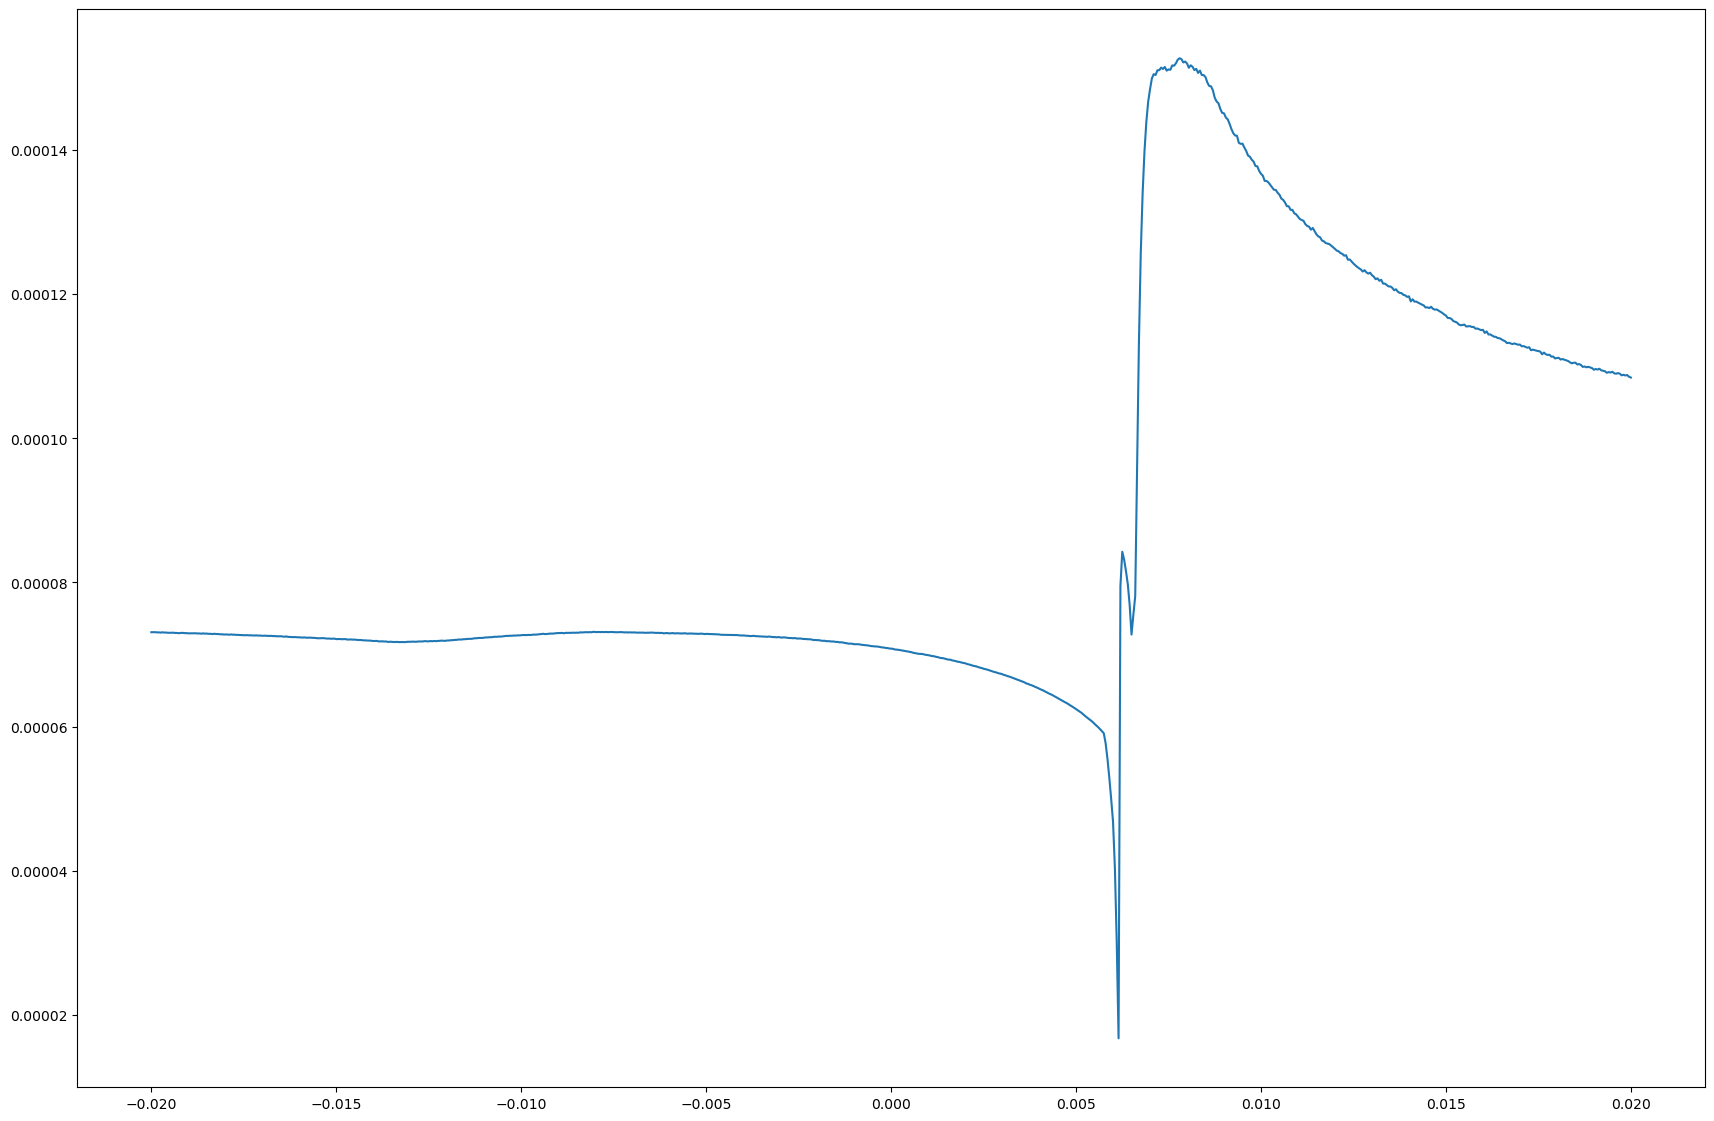

In [22]:
fig = plt.figure(figsize=(21, 14))
ax = fig.add_subplot(111)
ax.plot(deltays, stuff[:,3])